In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

In [2]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap, to_hex

def rotate_and_recalculate_xy(dot_df, line_df):
    dot = dot_df.copy()
    line = line_df.copy()

    dot_layer1 = dot[dot['layer'] > 1].copy()
    bin_edges = np.linspace(-np.pi, np.pi, 360)
    dot_layer1['angle_bin'] = pd.cut(dot_layer1['angle'], bins=bin_edges, include_lowest=True)
    counts = dot_layer1['angle_bin'].value_counts().sort_index()

    regions = []
    current_start = None

    for i in range(len(counts)):
        if counts.iloc[i] == 0:
            if current_start is None:
                current_start = bin_edges[i]
        else:
            if current_start is not None:
                regions.append((current_start, bin_edges[i]))
                current_start = None
    if current_start is not None:
        regions.append((current_start, bin_edges[-1]))

    max_len = 0
    best = None
    for s, e in regions:
        l = e - s
        if l > max_len:
            max_len = l
            best = (s, e)

    mid = (best[0] + best[1]) / 2
    target = np.pi / 2
    rotate = target - mid

    dot['angle_rotated'] = dot['angle'] + rotate
    r = dot['layer_f']
    theta = dot['angle_rotated']
    dot['x'] = r * np.cos(theta)
    dot['y'] = r * np.sin(theta)

    coord_map = dot.set_index('acc')[['x', 'y']].to_dict('index')
    line['source_x'] = line['source'].map(lambda a: coord_map[a]['x'])
    line['source_y'] = line['source'].map(lambda a: coord_map[a]['y'])
    line['target_x'] = line['target'].map(lambda a: coord_map[a]['x'])
    line['target_y'] = line['target'].map(lambda a: coord_map[a]['y'])

    return dot, line

set1 = plt.cm.Set1.colors

mobility_map = {
    'non-mobilizable': set1[0],
    'mobilizable': set1[2],
    'conjugative': set1[1]
}

amr_map = {
    'AMR': set1[-2],
    'non-AMR': set1[-1]
}


genus_name = 'Escherichia' # 'Enterobacter' #
base_folder = '/active-data/analysis_results/chr_pla/genus'
replicon_data = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
dot_sample = pd.read_csv(f'{base_folder}/figure_data/circle_layer_network_output/{genus_name}/all_dot_table.csv')
line_sample = pd.read_csv(f'{base_folder}/figure_data/circle_layer_network_output/{genus_name}/all_link_table.csv')

dot_sample, line_sample = rotate_and_recalculate_xy(dot_sample, line_sample)

mob_type = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/annotations/NMS_replicon_mobtyper_results.tsv', sep='\t', index_col=0)
mob_type = mob_type.rename(columns={'id': 'acc'})
amr_type = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/annotations/NMS_replicon_AMRtyper_results.tsv', sep='\t', index_col=0)
amr_type = amr_type.drop_duplicates(subset=['accession'], keep='first')
amr_type = amr_type.rename(columns={'accession': 'acc'})

dot_merged = pd.merge(dot_sample, mob_type[['acc', 'predicted_mobility']], on='acc', how='left')
dot_merged = pd.merge(dot_merged, amr_type, on='acc', how='left')
dot_merged['color_mobility'] = dot_merged['predicted_mobility'].map(mobility_map)
dot_merged['color_amr'] = dot_merged['AMR_type'].map(amr_map)
dot_merged['layer_new'] = np.ceil(dot_merged['layer']) - 1
dot_merged['layer_new'] = dot_merged['layer_new'].astype(int)
dot_merged = pd.merge(dot_merged, replicon_data[['accession', 'size', 'average plasmid fraction-pident_90']].rename(columns={'accession': 'acc', 'average plasmid fraction-pident_90': 'plasmidness'}), on='acc', how='left')
dot_merged['log10_size'] = np.log10(dot_merged['size'])

plasmidness_cmap = LinearSegmentedColormap.from_list(
    "plasmidness_blue_yellow", ["#ff7f0e", '#a5d6a5', "#cce7ff"]
)
dot_merged['color_plasmidness'] = dot_merged['plasmidness'].apply(
    lambda x: to_hex(plasmidness_cmap(x))
)

In [3]:
def plot_genome(ax, dot_merged, line_sample, color_col, edge_line=False):
    ax.plot(
        [line_sample['source_x'], line_sample['target_x']],
        [line_sample['source_y'], line_sample['target_y']],
        color='lightgray',
        linewidth=0.4,
        alpha=0.3
    )
    if edge_line:
        linewidth=0.05
    else:
        linewidth=0
    ax.scatter(
        dot_merged['x'],
        dot_merged['y'],
        c=dot_merged[color_col],
        s=3,
        alpha=0.8,
        zorder=10,
        edgecolors='black',
        linewidth=linewidth
    )

    max_val = np.ceil(dot_merged['layer'].max())
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)

    unique_layers = sorted(dot_merged['layer'].unique())
    theta = np.linspace(0, 2*np.pi, 200)
    for r in unique_layers:
        if r >= 0.7:
            ax.plot(r*np.cos(theta), r*np.sin(theta), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axis('off')

In [4]:
from Bio import SeqIO
from Bio.SeqFeature import CompoundLocation

def load_gbff_with_bio(gbff_path, target_contig_id=None):
    contig_list = []
    for record in SeqIO.parse(gbff_path, "genbank"):
        rec_id = record.id
        if target_contig_id is not None and rec_id != target_contig_id:
            continue
        rec_len = len(record.seq)
        gene_groups = []
        for feat in record.features:
            feat_type = feat.type
            if feat_type not in ("CDS", "tRNA", "rRNA"):
                continue
            loc = feat.location
            rev = loc.strand == -1
            subs = loc.parts if isinstance(loc, CompoundLocation) else [loc]
            seg_coords = [(p.start, p.end) for p in subs]
            gene_groups.append((feat_type, rev, seg_coords))
        contig_list.append((rec_id, rec_len, gene_groups))
    return contig_list

def draw_gbff_block_features(ax, contig, x_pos, y_pos):
    ctg_id, total_bp, gene_groups = contig
    feat_color = {"CDS":"#e74c3c","tRNA":"#2ecc71","rRNA":"#f39c12"}
    feat_edge = "#222222"
    full_tri_h = 0.5
    rect_h = full_tri_h * 0.65
    arrow_len = 300 #max(total_bp * 0.07, 35)
    h_tri_half = full_tri_h / 2
    h_rect_half = rect_h / 2
    for f_type, rev, seg_list in gene_groups:
        fill_c = feat_color[f_type]
        if len(seg_list) > 1:
            all_p = []
            for s,e in seg_list: all_p.extend([s,e])
            min_p,max_p = min(all_p),max(all_p)
            seg_sorted = sorted(seg_list, key=lambda x:x[0])
            if max_p - min_p == total_bp:
                gaps = []
                for i in range(len(seg_sorted)-1):
                    s_curr,e_curr = seg_sorted[i]
                    s_next,_ = seg_sorted[i+1]
                    gaps.append(s_next - e_curr)
                wrap_gap_idx = np.argmax(gaps)
                seg_bounds = seg_sorted[wrap_gap_idx+1:] + seg_sorted[:wrap_gap_idx+1]
            else:
                seg_bounds = seg_sorted
        else:
            seg_bounds = seg_list
        if not rev:
            tip_seg_idx = len(seg_bounds) - 1
        else:
            tip_seg_idx = 0
        for seg_idx,(s_seg,e_seg) in enumerate(seg_bounds):
            seg_len = e_seg - s_seg
            s_draw = x_pos + s_seg
            e_draw = x_pos + e_seg
            if seg_idx != tip_seg_idx:
                rect_poly = np.array([[s_draw, y_pos + h_rect_half],[s_draw, y_pos - h_rect_half],[e_draw, y_pos - h_rect_half],[e_draw, y_pos + h_rect_half],[s_draw, y_pos + h_rect_half]])
                p = plt.Polygon(rect_poly, facecolor=fill_c, alpha=0.75, ec=feat_edge, lw=0.5, zorder=3)
                ax.add_patch(p)
            else:
                rect_len = seg_len - arrow_len
                poly_points = []
                if rect_len <= 0:
                    if rev:
                        poly_points = np.array([[s_draw, y_pos],[e_draw, y_pos - h_tri_half],[e_draw, y_pos + h_tri_half],[s_draw, y_pos]])
                    else:
                        poly_points = np.array([[e_draw, y_pos],[s_draw, y_pos - h_tri_half],[s_draw, y_pos + h_tri_half],[e_draw, y_pos]])
                else:
                    if rev:
                        tri_tip = s_draw
                        joint_x = s_draw + arrow_len
                        poly_points = np.array([[tri_tip, y_pos],[joint_x, y_pos + h_tri_half],[joint_x, y_pos + h_rect_half],[e_draw, y_pos + h_rect_half],[e_draw, y_pos - h_rect_half],[joint_x, y_pos - h_rect_half],[joint_x, y_pos - h_tri_half],[tri_tip, y_pos]])
                    else:
                        tri_tip = e_draw
                        joint_x = e_draw - arrow_len
                        poly_points = np.array([[tri_tip, y_pos],[joint_x, y_pos + h_tri_half],[joint_x, y_pos + h_rect_half],[s_draw, y_pos + h_rect_half],[s_draw, y_pos - h_rect_half],[joint_x, y_pos - h_rect_half],[joint_x, y_pos - h_tri_half],[tri_tip, y_pos]])
                gene_poly = plt.Polygon(poly_points, facecolor=fill_c, alpha=0.75, ec=feat_edge, lw=0.5, zorder=3)
                ax.add_patch(gene_poly)

In [5]:
# sequence_aligment_picture
from Bio import SeqIO
import matplotlib.colors as mcolors
import matplotlib.path as mpath

def identity_to_color(base_hex, identity, ID_MIN=70, ID_MAX=100):
    FIXED_ALPHA = 0.8
    identity = np.clip(identity, ID_MIN, ID_MAX)
    ratio = (identity - ID_MIN) / (ID_MAX - ID_MIN)
    base_rgb = np.array(mcolors.hex2color(base_hex))
    start_rgb = (np.array([1.0, 1.0, 1.0]) * 2/3) + (base_rgb * 1/3)
    final_rgb = start_rgb * (1 - ratio) + base_rgb * ratio
    return (*final_rgb, FIXED_ALPHA)

def plot_synteny_blocks(ax, df, s1_line, s2_line, BASE_NORMAL="#bbbbbb", BASE_CROSS="#73a9c2", ID_MIN=70, ID_MAX=100, FIXED_ALPHA=0.5):
    s1_x_data = s1_line[0].get_xdata()
    s1_y_data = s1_line[0].get_ydata()

    s1_x_start = s1_x_data[0]
    s1_x_end   = s1_x_data[1]
    s1_y       = s1_y_data[0]

    s2_x_data = s2_line[0].get_xdata()
    s2_y_data = s2_line[0].get_ydata()

    s2_x_start = s2_x_data[0]
    s2_x_end   = s2_x_data[1]
    s2_y       = s2_y_data[0]

    def draw_single_band(s1_start, s1_end, s2_start, s2_end, identity):
        mid_y = (s1_y + s2_y) / 2
        dir_s1 = s1_end > s1_start
        dir_s2 = s2_end > s2_start
        is_cross = dir_s1 != dir_s2

        base = BASE_CROSS if is_cross else BASE_NORMAL
        color = identity_to_color(base, identity, ID_MIN=ID_MIN, ID_MAX=ID_MAX)

        verts = [
            (s1_start + s1_x_start, s1_y),
            (s1_start + s1_x_start, mid_y),
            (s2_start + s2_x_start, mid_y),
            (s2_start + s2_x_start, s2_y),
        
            (s2_end   + s2_x_start, s2_y),
            (s2_end   + s2_x_start, mid_y),
            (s1_end   + s1_x_start, mid_y),
            (s1_end   + s1_x_start, s1_y),
        
            (s1_start + s1_x_start, s1_y)
        ]
        
        codes = [
            mpath.Path.MOVETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO,
            mpath.Path.LINETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO, mpath.Path.CLOSEPOLY
        ]
        patch = mpatches.PathPatch(mpath.Path(verts, codes), facecolor=color, edgecolor="none")
        ax.add_patch(patch)

    for _, row in df.iterrows():
        draw_single_band(
            row["qstart"], row["qend"],
            row["sstart"], row["send"],
            row["pident"]
        )

def sequence_alignment(query_acc, sub_acc, contig_dict, ident_thr=90, len_thr=0):
    for acc_n in [query_acc, sub_acc]:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        os.chdir('/active-data/temp')
        temp_ncl_file = open(f'temp_nucleotide_seq-{acc_n}.fasta', 'w+')
        for seq_record in acc_record:
            if seq_record.id in contig_dict[acc_n]:
                SeqIO.write(seq_record, temp_ncl_file, "fasta")
        temp_ncl_file.close()
        handle.close()
    
    os.chdir('/active-data/temp')
    %time os.system(f'blastn -query temp_nucleotide_seq-{query_acc}.fasta -subject temp_nucleotide_seq-{sub_acc}.fasta -out blastn_results.txt -evalue 1e-50 -max_target_seqs 100000 -outfmt 6')
    head = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
    align_result = pd.read_csv('blastn_results.txt', sep = '\t', engine = 'python', header = None, names = head)
    align_result = align_result[(align_result['pident'] >= ident_thr) & (align_result['length'] >= len_thr)].reset_index(drop=True)
    os.system(f'rm temp_nucleotide_seq-{query_acc}.fasta')
    os.system(f'rm temp_nucleotide_seq-{sub_acc}.fasta')
    return align_result

def sequence_len(contig_dict):
    len_dict = {}
    for acc_n in contig_dict:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        for seq_record in acc_record:
            if seq_record.id in contig_dict[acc_n]:
                len_dict[seq_record.id] = len(seq_record)
        handle.close()
    return len_dict

def draw_colorbar_legend(ax, rel_x=0.80, rel_y=0.85, width=0.02, height=0.25, gap=0.01, ID_MIN=70, ID_MAX=100):
    n_steps = 50
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    data_w = x1 - x0
    data_h = y1 - y0

    x_start = x0 + rel_x * data_w
    y_top = y0 + rel_y * data_h
    y_bottom = y_top - height * data_h

    x1_left = x_start
    x1_right = x_start + width * data_w
    x2_left = x1_right + gap * data_w
    x2_right = x2_left + width * data_w

    ys = np.linspace(y_top, y_bottom, n_steps)
    dy = ys[1] - ys[0]

    BASE_NORMAL = "#bbbbbb"
    BASE_CROSS  = "#73a9c2"

    for i in range(n_steps):
        id_val = ID_MAX - (ID_MAX - ID_MIN) * (i / (n_steps - 1))
        c1 = identity_to_color(BASE_NORMAL, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        c2 = identity_to_color(BASE_CROSS, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        ax.fill_between([x1_left, x1_right], ys[i], ys[i]+dy, color=c1, ec="none")
        ax.fill_between([x2_left, x2_right], ys[i], ys[i]+dy, color=c2, ec="none")

    ax.plot([x1_left, x1_right, x1_right, x1_left, x1_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)
    ax.plot([x2_left, x2_right, x2_right, x2_left, x2_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)

    mid_x = (x1_left + x2_right) / 2
    ax.text(x1_left, (y_top + y_bottom)/2, "Identity", ha="right", va="bottom")
    ax.text(mid_x, y_top + 0.02, f"{ID_MAX}%", ha="center", va="bottom")
    ax.text(mid_x, y_bottom - 0.1, f"{ID_MIN}%", ha="center", va="top")

def add_length_bar(ax, bar_length=2000):
    x_max = ax.get_xlim()[1]
    x_start = x_max * 0.8
    y_pos = 0.5
    ax.plot([x_start, x_start + bar_length], [y_pos, y_pos], color='black', lw=1)
    ax.plot([x_start, x_start], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.plot([x_start+bar_length, x_start+bar_length], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.text(x_start + bar_length/2, y_pos - 0.15, f'{bar_length} bp', ha='center', va='top')

def get_align_results(acc_list):
    all_result = []
    for i in range(len(acc_list) - 1):
        query_acc = acc_list[i]
        sub_acc = acc_list[i+1]
        align_result = sequence_alignment(query_acc, sub_acc, contig_dict)
        all_result.append(align_result)
    return pd.concat(all_result, ignore_index=True)

def alignment_draw(ax, acc_list, contig_dict, align_result, feature=True):
    len_dict = sequence_len(contig_dict)
    acc_len = {}
    lines = {}
    gap_len = 1000
    for i in range(len(acc_list)):
        acc = acc_list[i]
        site = 0
        y_site = len(acc_list) - i - 1 + 0.5
        # ax.text(site-gap_len/3, y_site, acc, ha='right', va='center')
        for j in range(len(contig_dict[acc])):
            space = 0.2
            contig = contig_dict[acc][j]
            acc_len[acc] = site + len_dict[contig]
            lines[f'{acc}-{contig}'] = ax.plot([site, len_dict[contig] + site], [y_site, y_site], lw=1, color='black')
            if feature:
                gbff_file = f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc}/genomic.gbff'
                contig_list = load_gbff_with_bio(gbff_file, contig)
                for row_idx, ctg_data in enumerate(contig_list):
                    draw_gbff_block_features(ax, ctg_data, site, y_site)
            ax.text(site-gap_len/3, y_site, f'{contig} (L{i})', ha='right', va='center')
            site += gap_len + len_dict[contig]
    
    for i in range(len(acc_list) - 1):
        query_acc = acc_list[i]
        sub_acc = acc_list[i+1]
    
        for s1 in contig_dict[query_acc]:
            y1_site = 1.5 + i
            s1_line = lines[f'{query_acc}-{s1}']
            for s2 in contig_dict[sub_acc]:
                y2_site = 0.5 + i
                s2_line = lines[f'{sub_acc}-{s2}']
                plot_synteny_blocks(ax, align_result[(align_result['qseqid'] == s1) & (align_result['sseqid'] == s2)], s1_line, s2_line, ID_MIN=90)
    
    ax.set_xlim(-max(acc_len.values())*0.1, max(acc_len.values())*1.2)
    ax.set_ylim(0, len(acc_list))
    draw_colorbar_legend(ax, rel_x=0.8, ID_MIN=90, width=0.08)
    add_length_bar(ax, bar_length=1000)
    ax.axis("off")

In [6]:
def plot_stacked_percentage(ax, df, category_col, color_col):
    counts = df.groupby(['layer_new', category_col]).size().unstack(fill_value=0)
    percent = counts.div(counts.sum(axis=1), axis=0) * 100

    color_dict = {}
    for cat in df[category_col].unique():
        color = df[df[category_col] == cat][color_col].iloc[0]
        if isinstance(color, str):
            color = eval(color)
        color_dict[cat] = color
    cats = percent.columns.tolist()
    plot_colors = [color_dict[col] for col in percent.columns]

    x = np.arange(len(percent.index))
    width = 0.9
    bottom = np.zeros(len(percent.index))

    for i, cat in enumerate(cats):
        if len(cat) > 0 and not cat[0].isupper():
            cat_label = cat[0].upper() + cat[1:]
        else:
            cat_label = cat
        ax.bar(
            x, percent[cat], width, bottom=bottom,
            label=cat_label, color=plot_colors[i], alpha=0.8,
        )
        for j, (p, raw_val) in enumerate(zip(percent[cat], counts[cat])):
            if p > 0:
                ax.text(
                    x[j], bottom[j] + p/2,
                    str(int(raw_val)),
                    ha='center', va='center', fontsize=7, color='black'
                )
        bottom += percent[cat]

    ax.set_xticks(x)
    ax.set_xticklabels(percent.index, rotation=0)
    ax.set_xlim(-0.5, len(x)-0.5)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Layer')
    ax.set_ylim(0, 100)
    title_label = category_col.replace('_', ' ')
    if not title_label[0].isupper():
        title_label = title_label.capitalize()
    ax.legend(title=title_label, bbox_to_anchor=(1.05, 1), loc='upper left')

def plot_size_violin(ax, df, value_col):
    layers = sorted(df['layer_new'].unique())
    data = [df[df['layer_new'] == l][value_col].values for l in layers]
    
    parts = ax.violinplot(
        data, positions=layers, widths=0.7,
        showmeans=False, showmedians=False, showextrema=False
    )
    
    for pc in parts['bodies']:
        pc.set_facecolor('#88aaff')
        pc.set_edgecolor('black')
        pc.set_alpha(0.4)

    box_plot = ax.boxplot(
        data,
        positions=layers,
        widths=0.2,
        patch_artist=True,
        showmeans=False,
        showfliers=False,
        medianprops={'color': 'crimson', 'linewidth': 1},
        boxprops={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.8},
        whiskerprops={'color': 'black', 'linewidth': 1},
        showcaps=False
    )
    
    label = value_col.replace('_', ' ')
    if not label[0].isupper():
        label = label.capitalize()

    ax.set_xticks(layers)
    ax.set_xticklabels(layers)
    ax.set_xlabel('Layer')
    ax.set_ylabel(label)
    # ax.legend(loc='best')

In [7]:
# sequence_align
contig_list = ['GCF_037555585.1-NZ_CP148397.1', 'GCF_036884795.1-NZ_CP145713.1', 'GCF_030162155.2-NZ_AP027968.1', 'GCF_000019645.1-NC_010487.1', 'GCF_024918295.1-NZ_CP103653.1', 'GCF_036503025.1-NZ_AP027747.1', 'GCF_013340805.1-NZ_AP023203.1', 'GCF_027945055.1-NZ_CP116201.1']
acc_list = []
contig_dict = {}
for contig in contig_list:
    acc_n, contig = contig.split('-')
    acc_list.append(acc_n)
    if acc_n not in contig_dict:
        contig_dict[acc_n] = []
    contig_dict[acc_n].append(contig)

align_result = get_align_results(acc_list)

CPU times: user 406 μs, sys: 24 μs, total: 430 μs
Wall time: 2.03 s
CPU times: user 372 μs, sys: 0 ns, total: 372 μs
Wall time: 761 ms
CPU times: user 343 μs, sys: 19 μs, total: 362 μs
Wall time: 711 ms
CPU times: user 336 μs, sys: 18 μs, total: 354 μs
Wall time: 799 ms
CPU times: user 324 μs, sys: 16 μs, total: 340 μs
Wall time: 734 ms
CPU times: user 351 μs, sys: 17 μs, total: 368 μs
Wall time: 801 ms
CPU times: user 429 μs, sys: 20 μs, total: 449 μs
Wall time: 1.84 s


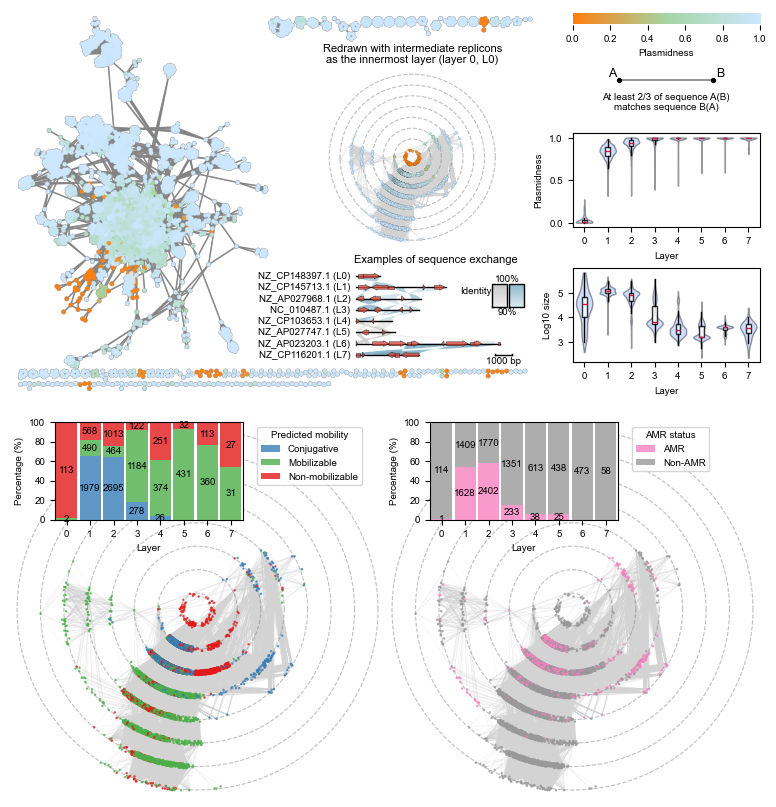

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

def arrow_legend(ax):
    xA, yA = 1, 1
    xB, yB = 3, 1
    
    ax.scatter(xA, yA, s=8, c="black", zorder=5)
    ax.scatter(xB, yB, s=8, c="black", zorder=5)
    
    ax.text(xA-0.15, yA+0.08, "A", fontsize=9, ha="center")
    ax.text(xB+0.15, yB+0.08, "B", fontsize=9, ha="center")
    
    dx = xB - xA
    dy = yB - yA
    move_x = 0
    tip_x, tip_y = xB+move_x, yB
    head_len = 0 #0.3
    head_wid = 0.04
    p1 = (tip_x - head_len, tip_y + head_wid)
    p2 = (tip_x - head_len, tip_y - head_wid)
    
    ax.plot([xA, xB - head_len], [yA, yB], color="gray", linewidth=1.2, zorder=3)
    #triangle = patches.Polygon([p1, p2, (tip_x, tip_y)], facecolor="black", edgecolor="none", zorder=4)
    #ax.add_patch(triangle)
    
    ax.text(
        (xA+xB)/2, 0.3,
        "At least 2/3 of sequence A(B)\nmatches sequence B(A)",
        ha="center", fontsize=7
    )
    
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 1.8)
    ax.axis("off")

fig = plt.figure(figsize=(7.5, 7.5))

img = mpimg.imread(f"{base_folder}/statistics_records/{genus_name}/{genus_name}_sub_replicon_link.csv_cut_no_arrow.png")
img_height, img_width = img.shape[:2]

ax_link_height = 0.52
ax_link_fig = fig.add_axes([0,1-ax_link_height,ax_link_height/img_height*img_width,ax_link_height])
ax_link_fig.imshow(img)
ax_link_fig.axis("off")

plasmidness_cmap = LinearSegmentedColormap.from_list(
    "plasmidness_blue_yellow", ["#ff7f0e", '#a5d6a5', "#cce7ff"]
)
cbar_x = 0.75
ax_cbar = fig.add_axes([cbar_x,0.98,1-cbar_x,0.015])
ax_cbar.set_xlim(0, 1)
ax_cbar.set_ylim(0, 1)
gradient = np.linspace(0, 1, 256).reshape(1, -1)
im = ax_cbar.imshow(gradient, cmap=plasmidness_cmap, aspect='auto', extent=[0,1,0,1], zorder=1, alpha=1)
ax_cbar.set_xlabel('Plasmidness', fontsize=7)
ax_cbar.spines[['top', 'bottom', 'right', 'left']].set_visible(False)
ax_cbar.set_yticks([])

ax_arrow = fig.add_axes([cbar_x,0.85,1-cbar_x,0.1])
arrow_legend(ax_arrow)

ax_layer = fig.add_axes([ax_link_height/img_height*img_width*0.6,1-ax_link_height + ax_link_height*0.4,0.23,0.23])
plot_genome(ax_layer, dot_merged, line_sample, 'color_plasmidness', edge_line=True)
ax_layer.set_title('Redrawn with intermediate replicons\nas the innermost layer (layer 0, L0)')

ax_sequence_align = fig.add_axes([ax_link_height/img_height*img_width*0.63,1-ax_link_height + ax_link_height*0.1,0.25,0.12])
ax_sequence_align.set_title('Examples of sequence exchange')
alignment_draw(ax_sequence_align, acc_list, contig_dict, align_result)

violin_x = 0.75
violin_space = 0.055
violin_height = ax_link_height/2-violin_space-0.08
plasmidness_bottom = 1-ax_link_height + violin_height+violin_space + 0.05
ax_plasmidness = fig.add_axes([violin_x,plasmidness_bottom,1-violin_x,violin_height])
plot_size_violin(ax_plasmidness, dot_merged, 'plasmidness')

size_bottom = 1-ax_link_height + 0.05
ax_size = fig.add_axes([violin_x,size_bottom,1-violin_x,violin_height])
plot_size_violin(ax_size, dot_merged, 'log10_size')

circle_bottom = 0.05 - 0.1

ax_mob = fig.add_axes([0,circle_bottom,0.5,0.5])
plot_genome(ax_mob, dot_merged, line_sample, 'color_mobility')

ax_amr = fig.add_axes([0.5,circle_bottom,0.5,0.5])
plot_genome(ax_amr, dot_merged, line_sample, 'color_amr')

ax_mob_sta = fig.add_axes([0+0.06,circle_bottom+0.37,0.25,0.13])
plot_stacked_percentage(ax_mob_sta, dot_merged, category_col='predicted_mobility', color_col='color_mobility')
ax_amr_sta = fig.add_axes([0.5+0.06,circle_bottom+0.37,0.25,0.13])
dot_merged = dot_merged.rename(columns={'AMR_type': 'AMR_status'})
plot_stacked_percentage(ax_amr_sta, dot_merged, category_col='AMR_status', color_col='color_amr')

figure_fold = f'{base_folder}/figures'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig(f"{genus_name}_circle_network.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{genus_name}_circle_network.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()